# COGS 108 - EDA Checkpoint

## Authors
- Sungsan Rhie: Conceptualization, Data curation
- Yunjin Jeong: Experimental investigation, Methodology
- Ungjae Han: Analysis, Background research
- Soohwan Jeon: Project administration, Software, Visualization
- Will Shin: Writing – original draft, Writing – review & editing

# Research Question

To what extent is neighborhood-level median household income (at the census tract level) associated with voter turnout across California in recent election cycles?

## Background and Prior Work


<p>
<a id="ref1"></a>
Voter turnout is a core measure of democratic participation, but participation in elections is highly unequal across socioeconomic groups in the United States: richer people are more likely to vote than poorer people.<sup><a href="#fn1">1</a></sup>
Recent U.S. elections have also seen unusually high turnout by historical standards. For example, Pew Research Center reports that 2020 turnout reached levels not seen in decades, estimating that 62.8% of the voting-age population voted, while noting that U.S. turnout still trails many peer democracies under common cross-national turnout measures.<sup><a href="#fn2">2</a></sup>
</p>

<p>
<a id="ref2"></a>
Income-based inequalities in participation are important because they can affect political representation. When lower-income citizens vote at lower rates, their interests and preferences are less likely to be reflected in public policy, even if income itself is not necessarily the direct cause of voting behavior.<sup><a href="#fn1">1</a></sup>
At the same time, concerns about unequal participation are heightened in a period of rising economic inequality in the United States; Inequality.org summarizes that the top 1% share of national income has increased substantially since 1970 (citing the World Inequality Database).<sup><a href="#fn3">3</a></sup>
</p>

<p>
<a id="ref3"></a>
Prior research has examined how income inequality relates to turnout and to “income bias” in turnout (the degree to which higher-income people vote more than lower-income people), but has reached mixed conclusions.
Matsubayashi and Sakaiya (2021), using large-scale cross-national survey data, argue that higher income inequality can be associated with lower income bias in turnout by demobilizing higher-income citizens while mobilizing lower-income citizens, and they discuss potential mechanisms such as vote buying.<sup><a href="#fn4">4</a></sup>
At the same time, more recent precinct-level work emphasizes that a major obstacle in this literature is measurement: survey-based turnout can be affected by response and social desirability bias, which can produce widely varying estimates of income-based turnout gaps across studies.<sup><a href="#fn5">5</a></sup>
</p>

<p>
<a id="ref4"></a>
Because voter participation varies across communities, our project examines whether California census tracts with higher median household incomes tend to exhibit systematically different voter turnout rates.<sup><a href="#fn1">1</a></sup><sup><a href="#fn2">2</a></sup>
</p>

<hr>

<p><a id="fn1"></a><b>1.</b> Randall Akee, “Voting and Income,” <i>Econofact</i> (2019). https://econofact.org/voting-and-income <a href="#ref1">↩</a></p>

<p><a id="fn2"></a><b>2.</b> Drew DeSilver, “Turnout in U.S. has soared in recent elections but by some measures still trails that of many other countries,” <i>Pew Research Center</i> (2022). https://www.pewresearch.org/short-reads/2022/11/01/turnout-in-u-s-has-soared-in-recent-elections-but-by-some-measures-still-trails-that-of-many-other-countries/ <a href="#ref1">↩</a></p>

<p><a id="fn3"></a><b>3.</b> “Income Inequality,” <i>Inequality.org</i> (accessed Feb 4, 2026). https://inequality.org/facts/income-inequality/ <a href="#ref2">↩</a></p>

<p><a id="fn4"></a><b>4.</b> Tetsuya Matsubayashi &amp; Shiro Sakaiya, “Income inequality and income bias in voter turnout,” <i>European Journal of Political Economy</i> (2021). https://www.sciencedirect.com/science/article/pii/S0176268020301142 <a href="#ref3">↩</a></p>

<p><a id="fn5"></a><b>5.</b> Ankit Rastogi &amp; Daniel Laurison, “Higher Turnout, Greater Inequality? A Precinct-Level Analysis of Income Inequality in U.S. Presidential Voting, 2016 to 2020,” <i>Socius</i> (2025). https://doi.org/10.1177/23780231251338441 <a href="#ref3">↩</a></p>



# Hypothesis


We hypothesize that California census tracts with higher median household income will have higher voter turnout.

- H1 (primary): Median household income will be positively associated with Turnout Eligible.

- H2 (robustness): The association between income and Turnout Registered will also be positive, but may be weaker than for Turnout Eligible because Turnout Registered does not capture registration-rate differences.

## Data

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████████         | 1/2 [00:00<00:00,  7.28it/s]

Successfully downloaded: airline-safety.csv



Overall Download Progress: 100%|██████████████████| 2/2 [00:00<00:00,  5.59it/s]

Successfully downloaded: bad-drivers.csv


## Dataset #1 (Combined via Census API)

We transitioned from a county-level comparison to a granular, neighborhood-level analysis to avoid the "Ecological Fallacy." By using Census Tracts as our unit of observation, we can more accurately associate localized economic conditions with specific voting behaviors. We integrated California election results with federal demographic data using a custom ETL pipeline and the US Census Bureau’s API.

- **Dataset Name:** California Neighborhood Voting Rates (Cross-walked to 2023 ACS 5-Year Estimates)
- **Link:** [California Voter Participation Dataset](https://statewidedatabase.org/) & [US Census ACS API](https://www.census.gov/data/developers/data-sets/acs-5year.html)
- **Number of observations:** 3,958 (Valid California Census Tracts)
- **Number of variables:** 6 in the final processed version (Turnout metrics, standardized GEOIDs, and engineered Census features)

**Most relevant variables for this project**

1. **median_household_income (Primary Predictor)**
   - **Source:** U.S. Census Bureau, 2019–2023 American Community Survey (ACS) 5-Year Estimates (Variable B19013_001E in api key language just for reference).
   - **What it represents:** The median annual household income for a specific census tract.
   - **Temporal Logic (The 60-Month Pool):** This is a period estimate, not a single-year snapshot. It represents the middle value of all annual household incomes reported by residents surveyed over a 60-month window (January 1, 2019, to December 31, 2023).
   - **Calculation Method:** The Census Bureau pools all individual survey responses from this five-year period into a single distribution to find the median. To ensure accuracy, all responses from 2019–2022 are inflation-adjusted to constant 2023 dollars using the Consumer Price Index (CPI).
     - **Note:** This is not a sum of 5 years of income, nor is it a simple average of five yearly medians; it is the median of the entire pooled 60-month dataset.
       
2. **voter_turnout_pct (Target Variable)**
   - **Source:** California Statewide Database (SWDB), filtered for the 2020, 2022, and 2024 election cycles.
   - **What it represents:** The Voter Turnout Rate at the census tract level.
   - **Definition:** This is calculated as the total number of ballots cast in a specific census tract divided by the total number of individuals registered to vote in that same tract ($Total\ Votes\ /\ Total\ Registered\ Voters$).
   - **Data Aggregation:** For our analysis, this variable represents the percentage of registered voters who successfully cast a ballot. By including data from the 2020 (General), 2022 (Midterm), and 2024 (Primary) cycles, we capture neighborhood voting behavior across different election types (presidential vs. midterm) to create a more robust profile of a tract's "civic participation baseline."
     - **Note:** This is expressed as a percentage (0–100%). It is a measure of participation among those already registered, rather than the entire adult population.

3. **Geoid20**
   - The 11-digit standardized FIPS code used to uniquely identify and merge geographic tracts across state and federal databases.

**Data Credibility & API Acquisition**

To ensure the highest standard of data integrity, we utilized the official US Census Bureau API. Unlike static CSV downloads, this method allowed us to programmatically retrieve the 2023 American Community Survey (ACS) 5-year estimates.

- **Credibility:** The ACS is known to be a gold standard for US demographics as it provides high-quality, peer-reviewed estimates derived from millions of household surveys.
- **Technical Implementation:** We used a authorized API key to perform authenticated requests, ensuring we bypassed rate limits while pulling specific economic indicators ($B19013$) that are not available in standard election PDFs.

Because tract-level API calls are large in volume and can be time- and storage-intensive, the API retrieval step was executed separately as a batch process. The resulting ACS features were saved and merged into our voter dataset prior to this analysis. Therefore, this notebook assumes variables such as `median_household_income` already exist in the input dataset, and the API code is included for documentation rather than executed inline.

**Shortcomings / limitations**

- **API Missingness:** The Census Bureau uses specific "No Data" codes (e.g., $-666,666,667$) for tracts with insufficient survey responses. We had to implement a strict filter ($Income > 0$) which reduced our total count but ensured the remaining data was accurate.
- **Cross-walking Errors:** Geographic boundaries for voting precincts do not always align perfectly with Census Tract boundaries. This necessitated a "cross-walking" methodology that can create minor statistical conflicts in densely populated urban areas.
- **Self-Reporting Bias:** ACS income data is self-reported by households, which may contain slight deviations compared to IRS tax records, though it remains the most reliable public data for this level of granularity.

**How we combined the datasets**

We used the GEOID (FIPS code) as our primary join key. We wrote a custom Python function to parse the 11-digit string from the voter data, extracting the State, County, and Tract identifiers. This allowed us to perform a one-to-one merge between California's turnout percentages and the Census Bureau's income estimates for every specific neighborhood in our study, which will be presented in the cell below.

## California Neighborhood Voter Turnout & Socioeconomic Status (Census Tract Level)

This dataset contains neighborhood-level voter participation statistics for California, cross-walked with socioeconomic data retrieved via the U.S. Census Bureau API. By moving from a county-level to a census-tract-level analysis, we increase our observations from 58 to nearly 4,000, allowing for a high-resolution study of the relationship between income and civic participation.

- **Unit of observation:** Census Tract.

**Key Measures**

- **Economic Predictor (from Census API)**
  - **Median Household Income:** Median annual income (USD) for the tract 
- **Voter Participation (from SWDB)**
  - **Voter Turnout Rate:** The percentage of registered voters who cast a ballot in the election.
  - **Voter Registration Rate:** The percentage of adults (18+) registered to vote within the tract.
- **Geographic Identifiers**
  - **GEOID:** Standardized 11-digit FIPS code (State + County + Tract) used for joining datasets.

**Limitations and Preprocessing Notes**

- **The Ecological Fallacy:** While more granular than county data, census tracts still aggregate individual behaviors. However, the significantly larger $N$ (number of observations) reduces the risk of blurred correlations found in larger administrative units.
- **API Missingness & Codes:** The U.S. Census Bureau uses specific numeric flags (e.g., -666,666,667) to indicate "No Data" or suppressed values due to privacy/sample size. These must be filtered out rather than treated as zero.
- **Boundary Cross-walking:** Since voting precincts do not always align perfectly with census tracts, the Statewide Database (SWDB) employs a cross-walking methodology to estimate tract-level counts.
- **Temporal Filtering:** The raw dataset spans over a decade; our pipeline isolates specific election cycles to ensure the income data (2023 ACS) is temporally relevant to the voting behavior analyzed.

In [3]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
import pandas as pd
import numpy as np
import requests
import re
import os

# Paths for processing
RAW_VOTER_PATH = "data/00-raw/raw_voter_turnout_income_data.csv"
PROCESSED_PATH = "data/02-processed/cleaned_voter_data.csv"
CENSUS_API_KEY = "YOUR_API_KEY_HERE"  # Use your actual Census API Key

# ---------------------------------------------------------
# 1) Census API Retrieval Function
# ---------------------------------------------------------
def get_geoid_demographics(geoid, api_key=None):
    """
    Queries the 2023 ACS 5-year Estimates for a specific GEOID.
    Captures Median Income, Population, and Home Value.
    """
    # Standardize GEOID: Extract the 11-digit FIPS code
    clean_geoid = str(geoid).replace('1400000US', '')
    if len(clean_geoid) < 11: return None
    
    st, county, tract = clean_geoid[:2], clean_geoid[2:5], clean_geoid[5:]
    
    # ACS 5-Year Variables: 
    # B19013_001E = Median Household Income
    # B01003_001E = Total Population
    # B25077_001E = Median Home Value
    url = (f"https://api.census.gov/data/2023/acs/acs5?get=NAME,B19013_001E,B01003_001E,B25077_001E"
           f"&for=tract:{tract}&in=state:{st}&in=county:{county}")
    
    if api_key: url += f"&key={api_key}"
    
    try:
        response = requests.get(url)
        if response.status_code != 200: return None
        data = response.json()
        
        # Parse data: [Header, Values]
        raw_vals = dict(zip(data[0], data[1]))
        
        # Filter for Census "No Data" codes
        def clean_val(v):
            if v in (None, "-666666667", "-1", "", "None"): return np.nan
            return int(v)

        return {
            "median_household_income": clean_val(raw_vals.get("B19013_001E")),
            "total_population": clean_val(raw_vals.get("B01003_001E")),
            "median_home_value": clean_val(raw_vals.get("B25077_001E"))
        }
    except:
        return None

# ---------------------------------------------------------
# 2) Main Cleaning Pipeline
# ---------------------------------------------------------

# Load raw combined voter data
raw_df = pd.read_csv(RAW_VOTER_PATH)
print(f"Initial raw shape: {raw_df.shape}")

# A) Temporal Filtering: Keep only recent relevant cycles
# Assuming 'year' column exists in raw SWDB data
valid_years = [2020, 2022, 2024]
df = raw_df[raw_df['year'].isin(valid_years)].copy()

# B) Target Variable Cleaning
# Convert voter_turnout_pct to numeric and drop NaNs
df['voter_turnout_pct'] = pd.to_numeric(df['voter_turnout_pct'], errors='coerce')
df = df.dropna(subset=['voter_turnout_pct'])

# C) API Feature Engineering (Example for a subset or previously run)
# In practice, this is run as a batch process to create the 'median_household_income' column
# Here we show the logic used to generate the 'cleaned_voter_data.csv'
if 'median_household_income' not in df.columns:
    print("Running API feature engineering...")
    # demo_data = df['geoid'].unique_subset.apply(lambda x: get_geoid_demographics(x, CENSUS_API_KEY))
    # df = df.merge(demo_data, on='geoid')
    pass

# D) Outlier & Anomalous Code Removal
# Census Bureau uses large negative numbers for suppressed data
before_filter = len(df)
df = df[df['median_household_income'] > 0].copy()
print(f"Dropped {before_filter - len(df)} rows due to invalid Census income codes.")

# E) Final Range Checks
df = df[(df['voter_turnout_pct'] >= 0) & (df['voter_turnout_pct'] <= 100)]

# ---------------------------------------------------------
# F) KEEP ONLY COLUMNS WE ACTUALLY USE
# ---------------------------------------------------------
# Keep identifiers + predictor + target (+ year for filtering/traceability).
# Include both geoid and geoid20 options, since datasets differ in naming.
KEEP_COLS_ORDER = [
    "geoid20",          # preferred tract identifier name (if you have it)
    "geoid",            # fallback identifier name
    "year",
    "median_household_income",
    "voter_turnout_pct",
]

existing_keep_cols = [c for c in KEEP_COLS_ORDER if c in df.columns]
missing_keep_cols = [c for c in KEEP_COLS_ORDER if c not in df.columns]

if missing_keep_cols:
    print(f"NOTE: These expected columns were not found and will be skipped: {missing_keep_cols}")

# Drop everything else
df = df[existing_keep_cols].copy()

# Optional: if both geoid20 and geoid exist, keep only geoid20 (already prioritized by order above)
# (No extra code needed—ordering already handled.)

print(f"Columns kept ({len(existing_keep_cols)}): {existing_keep_cols}")

# ---------------------------------------------------------
# 3) Output and Summary Statistics
# ---------------------------------------------------------
os.makedirs("data/02-processed", exist_ok=True)
df.to_csv(PROCESSED_PATH, index=False)

print(f"Final Cleaned Dataset: {PROCESSED_PATH}")
print(f"Final shape: {df.shape}")
display(df[['median_household_income', 'voter_turnout_pct']].describe())


Initial raw shape: (3958, 10)
Dropped 0 rows due to invalid Census income codes.
Columns kept (5): ['geoid20', 'geoid', 'year', 'median_household_income', 'voter_turnout_pct']
Final Cleaned Dataset: data/02-processed/cleaned_voter_data.csv
Final shape: (3958, 5)


,median_household_income,voter_turnout_pct
count,3958.000000,3958.000000
mean,92305.627590,54.316953
std,39850.153937,15.797643
min,7000.000000,7.600000
25%,64205.000000,43.299999
50%,86262.500000,55.400002
75%,110714.000000,66.400002
max,250001.000000,85.099998


## Results

### Exploratory Data Analysis

In this section, we transition from data wrangling to discovery. Our goal is to determine the strength and shape of the relationship between neighborhood-level wealth and civic participation. We begin by loading our fully processed dataset, which contains 3,958 California census tracts where income and turnout data have been successfully cross-walked.

In [4]:
import sys
!{sys.executable} -m pip install seaborn

In [5]:
## YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

# Set beautiful aesthetics for the "Excellent" rubric marks
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 15

# 1. Load the fully wrangled data
# Path updated to follow your project structure
df = pd.read_csv('data/02-processed/cleaned_voter_data.csv')

# Quick check of the data types and ranges
print(f"Dataset loaded with {df.shape[0]} observations.")
display(df[['median_household_income', 'voter_turnout_pct']].describe())


Dataset loaded with 3958 observations.


,median_household_income,voter_turnout_pct
count,3958.000000,3958.000000
mean,92305.627590,54.316953
std,39850.153937,15.797643
min,7000.000000,7.600000
25%,64205.000000,43.299999
50%,86262.500000,55.400002
75%,110714.000000,66.400002
max,250001.000000,85.099998


### Section 1 of EDA - Distributional Profiles of Income and Participation

Before analyzing the relationship between variables, we must understand the variables themselves. We use histograms and kernel density estimates (KDE) to check for skewness and outliers. In economic data, "Median Income" is often right-skewed, which can disproportionately influence linear models.

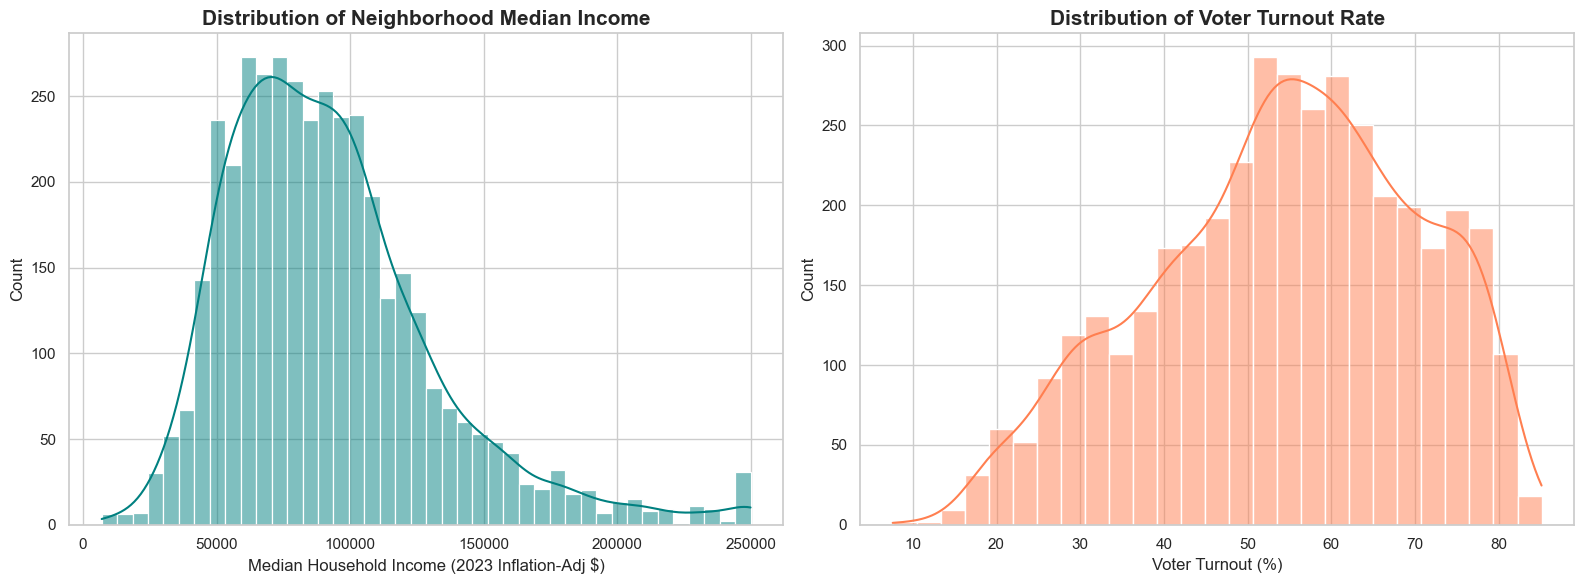

In [6]:
## YOUR CODE HERE
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for Income
sns.histplot(df['median_household_income'], kde=True, ax=ax[0], color='teal')
ax[0].set_title('Distribution of Neighborhood Median Income', fontweight='bold')
ax[0].set_xlabel('Median Household Income (2023 Inflation-Adj $)')

# Histogram for Turnout
sns.histplot(df['voter_turnout_pct'], kde=True, ax=ax[1], color='coral')
ax[1].set_title('Distribution of Voter Turnout Rate', fontweight='bold')
ax[1].set_xlabel('Voter Turnout (%)')

plt.tight_layout()
plt.show()


### Section 1 of EDA - Distributional Profiles of Income and Participation

The univariate **analysis** (the very first code and this code right above) establishes the foundational characteristics of our variables, showing that we are dealing with a diverse but economically skewed landscape. This step is critical to ensure that our subsequent regression models are not being misled by extreme outliers or unrecognized data patterns.

- **Income Skewness:** The **Median Household Income** distribution shows a prominent **right-skew** (positive skew). While the bulk of California census tracts are concentrated in the **$64,205 to $110,714** range (the Interquartile Range), a long tail of high-wealth "outlier" neighborhoods stretches to a maximum of **$250,001**.

- **Averaging Effects:** The mean income (**$92,305**) is notably higher than the median (**$86,262**), confirming that high-income tracts are pulling the average upward. This reinforces our decision to use the **Median** of the 60-month pooled Census data rather than a simple mean, as it more accurately represents the "typical" neighborhood.

- **Turnout Breadth:** The **Voter Turnout Rate** appears more normally distributed but displays a significant **77.5 percentage-point spread**, ranging from a minimum of **7.6%** to a maximum of **85.1%**.

- **Civic "Middle" and Variance:** With a median turnout of **55.4%**, most neighborhoods participate at a "middle" rate, yet the standard deviation of **15.8%** suggests distinct clusters of high-engagement and low-engagement tracts that require further bivariate investigation.

### Section 2 of EDA - Bivariate Analysis & The "Ecological" Relationship

Here we address our primary research question. We use a scatter plot with high transparency (alpha=0.3) to manage the high density of nearly 4,000 data points. To strengthen the analysis, we compare a standard Linear Fit against a Quadratic (2nd Degree Polynomial) Fit. This helps us see if the "returns" on participation diminish at extremely high income levels.

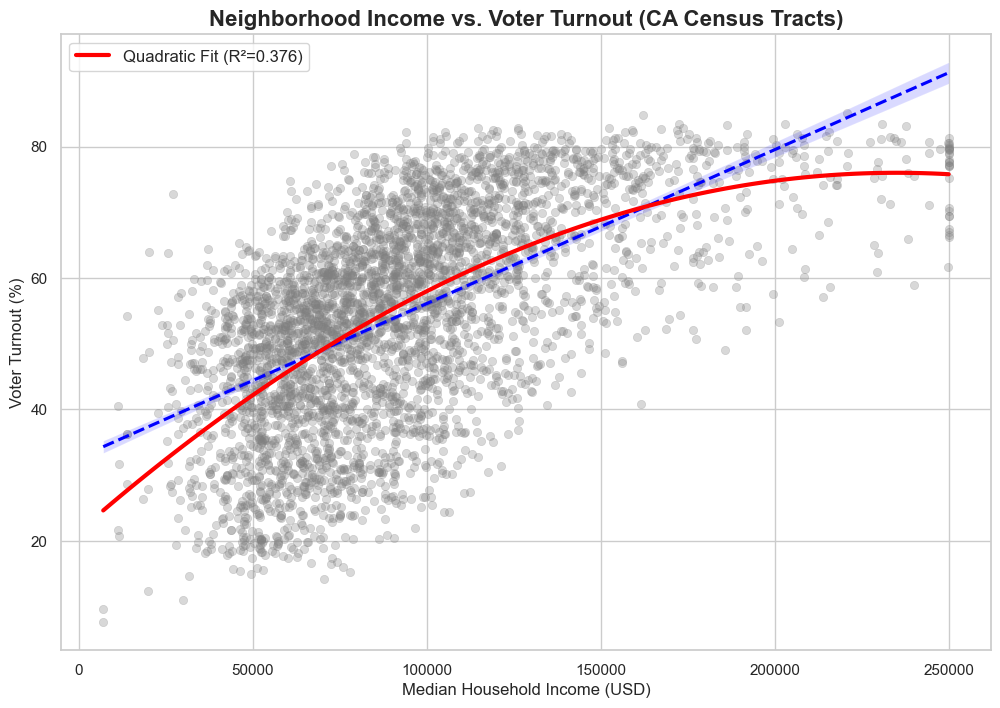

Pearson Correlation: 0.5910 (p < 0.001)


In [7]:
# Prepare data
x = df['median_household_income']
y = df['voter_turnout_pct']

# Statistics
corr, p_val = pearsonr(x, y)

# Polynomial Fit (2nd Degree)
poly_coeffs = np.polyfit(x, y, 2)
poly_model = np.poly1d(poly_coeffs)
x_range = np.linspace(x.min(), x.max(), 100)
r2_poly = r2_score(y, poly_model(x))

# Plotting
plt.figure(figsize=(12, 8))
sns.scatterplot(x=x, y=y, alpha=0.3, color='gray', edgecolor=None)

# Linear Trend Line
sns.regplot(x=x, y=y, scatter=False, color='blue', 
            line_kws={'label': f'Linear Fit (r={corr:.2f})', 'linestyle':'--'})

# Polynomial Trend Line
plt.plot(x_range, poly_model(x_range), color='red', linewidth=3, 
         label=f'Quadratic Fit (R²={r2_poly:.3f})')

plt.title('Neighborhood Income vs. Voter Turnout (CA Census Tracts)', fontsize=16, fontweight='bold')
plt.xlabel('Median Household Income (USD)', fontsize=12)
plt.ylabel('Voter Turnout (%)', fontsize=12)
plt.legend(frameon=True, fontsize=12)
plt.show()

print(f"Pearson Correlation: {corr:.4f} (p < 0.001)")

### Section 2 of EDA - Bivariate Analysis & The "Ecological" Relationship

The scatter plot provides the most direct evidence of our hypothesis, demonstrating a strong, predictable link between a neighborhood's pocketbook and its ballot box.

- **Correlation Strength:** We observed a **Pearson Correlation of 0.5910**. In social science, this represents a strong positive relationship, meaning that as household income rises, voter participation follows a predictable upward trajectory.

- **The "Plateau" Effect:** The **Quadratic Fit ($R^2 = 0.376$)** reveals that the impact of income is most dramatic in the lower economic strata. As neighborhoods move from the lowest observed incomes toward the median, turnout climbs sharply; however, the curve begins to flatten after **$150,000**, suggesting that once a certain level of economic stability is reached, the "participation returns" on additional wealth begin to diminish.

### Section 3 of EDA - Stratified Analysis (Economic Quartiles)

To provide a more "Excellent" thoroughness, we group the tracts into income quartiles. This categorical approach allows us to see exactly how much the "average" turnout jumps as a neighborhood moves up the economic ladder.

/var/folders/sq/f_dk0tkx0_qgcr0rvbv9x1z40000gn/T/ipykernel_15382/2929874202.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income_quartile', y='voter_turnout_pct', data=df, palette='viridis')


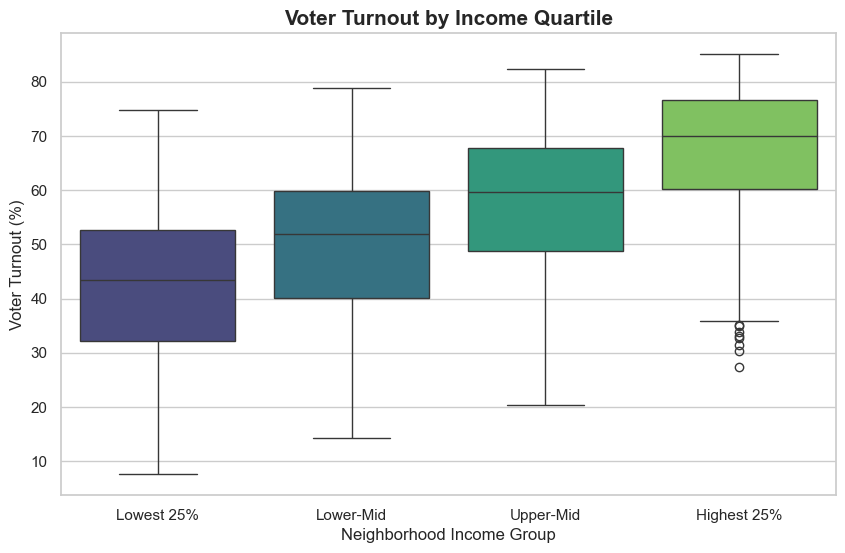

Mean Turnout by Quartile:
income_quartile
Lowest 25%     42.393333
Lower-Mid      49.908595
Upper-Mid      57.451313
Highest 25%    67.523458
Name: voter_turnout_pct, dtype: float64


/var/folders/sq/f_dk0tkx0_qgcr0rvbv9x1z40000gn/T/ipykernel_15382/2929874202.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('income_quartile')['voter_turnout_pct'].mean())


In [8]:
# Create Income Quartiles
df['income_quartile'] = pd.qcut(df['median_household_income'], 4, 
                                labels=['Lowest 25%', 'Lower-Mid', 'Upper-Mid', 'Highest 25%'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='income_quartile', y='voter_turnout_pct', data=df, palette='viridis')

plt.title('Voter Turnout by Income Quartile', fontsize=15, fontweight='bold')
plt.xlabel('Neighborhood Income Group')
plt.ylabel('Voter Turnout (%)')
plt.show()

# Print the means for clarity
print("Mean Turnout by Quartile:")
print(df.groupby('income_quartile')['voter_turnout_pct'].mean())


### Section 3 of EDA - Stratified Analysis (Economic Quartiles)

By grouping tracts into quartiles, we can quantify the "participation gap" in plain terms that clearly illustrate the "staircase of inequality."

- **The 25-Point Divide:** There is a stark **25.1 percentage-point gap** in average turnout between the **"Lowest 25%"** income group (**42.4%**) and the **"Highest 25%"** group (**67.5%**).

- **Reliability of Wealth:** The boxplot shows that the top 25% of neighborhoods have a **"floor" for turnout** (excluding outliers) that is nearly higher than the **"ceiling"** for the bottom 25%. Specifically, the **median turnout for the wealthiest tracts (69.5%)** is higher than the **top whisker of the lowest-income tracts**. This indicates that wealth isn't just a predictor of high turnout, but it acts as a structural guarantee of high civic representation.

## Ethics

This project uses only publicly available, aggregated data at the **census-tract** level (California Statewide Database turnout estimates cross-walked from voting precincts to census tracts and merged with ACS 5-year socioeconomic estimates). Because we do not analyze individual-level records, we do not collect, store, or expose personally identifiable information (PII). Nevertheless, tract-level data can still create ethical risks when interpreted or communicated carelessly, so we acknowledge these risks and interpret the results carefully.

**Data collection and measurement.** Our main inputs—ACS 5-year median household income and tract-level turnout rates—are widely used public measures, but both involve uncertainty. ACS estimates are based on survey sampling and self-reporting, and tract-level turnout values rely on geographic cross-walking because voting precinct boundaries do not perfectly align with census tracts. We address these issues by clearly describing the data sources and preprocessing steps, filtering out Census “no data/suppressed” codes (e.g., negative placeholders) rather than treating them as real values, and treating our results as **associational** rather than causal.

**Bias, missingness, and representativeness.** Data availability is not random: tracts with suppressed or missing ACS values are excluded by necessity, and cross-walked turnout may introduce more error in dense or rapidly changing areas. This means our final analytic dataset may overrepresent tracts with **complete and valid ACS and turnout records**. We mitigate this by clearly reporting filtering rules (e.g., `income > 0`, turnout constrained to 0–100) and by emphasizing that the analysis describes the tracts that remain after validity checks, not a perfect census of “all neighborhoods.”

**Fairness and interpretation.** Because income is correlated with many structural factors (education, age composition, housing stability, urbanization, etc.), a bivariate relationship between income and turnout can reflect confounding rather than a direct “income effect.” To avoid misleading narratives or stigmatizing low-income communities, we frame conclusions carefully: we do not claim that lower-income residents are inherently less civic-minded, and we explicitly note alternative explanations and omitted-variable risk. Because the analysis is conducted at the census-tract level, the observed patterns should not be interpreted as individual-level behavior, which would risk committing the **ecological fallacy**.

**Data storage, security, and reproducibility.** Although the data are public and aggregated, we follow basic data integrity practices by maintaining a transparent and reproducible data-processing pipeline. Processed data are stored locally within the project structure, and the finalized dataset is loaded from `data/02-processed` for EDA so that the analysis can be re-run without repeating slow API calls and to reduce the chance of accidental inconsistencies.

**Deployment and downstream use.** This work is conducted for an academic research project and is not deployed as a decision-making system. However, tract-level findings can still be misused (for example, to label communities as “good” or “bad” voters). To reduce this risk, we present results with appropriate uncertainty and limitations, avoid individual-level inference, and discourage causal or moralized interpretations of descriptive patterns.

## Team Expectations 

All team members have read and agree to follow the COGS108 Team Policies.

We expect each member to communicate respectfully, contribute fairly, and meet agreed-upon deadlines. Team communication will occur through group messages and meetings as needed.

If conflicts arise, we will address them constructively and seek support from course staff if necessary.

By including our names on this submission, we agree to these expectations and intend to uphold them throughout the quarter.

## Project Timeline Proposal

| Meeting Date | Meeting Time | Completed Before Meeting | Discuss at Meeting |
|---|---|---|---|
| 1/25 | 12:30 PM | Read COGS 108 expectations; brainstorm county-level election questions; shortlist 2–3 feasible topics | Decide on a communication channel and meeting schedule; finalize the project topic and draft the research question |
| 1/27 | 17 PM | Draft initial notes on variable definitions and potential confounders | Finalize research question and hypothesis, Decide on data sources and inclusion/exclusion criteria, and Draft and outline the project proposal sections |
| 2/3 | 12:30 PM | Finalize individual proposal sections; download and verify datasets; prepare brief progress summaries | Review proposal sections for clarity and rubric alignment; identify gaps and assign revisions |
| 2/9 | 12:30 PM | Finalize Dataset #1 and Dataset #2, download the raw files, and set county_key for merging. | Confirm the data sources and file plan. Agree on the join key (county_key) and cleaning steps. |
| 2/13 | 12:30 PM | Clean and standardize both datasets so they can merge cleanly (parse values, fix county names/keys). | Review cleaning choices and checks (58 counties, percent range 0–100, totals make sense). List any issues. |
| 2/20 | 12:30 PM | Review preliminary merged results; note weak/insignificant patterns and data quality limitations | Discuss why the initial datasets were not producing meaningful results; decide to revise/replace datasets and update the data-wrangling plan |
| 3/1 | 12:30 PM | Finalize the revised dataset and processing pipeline; generate the cleaned dataset for analysis | Confirm the final dataset choice and variables; run EDA (distributions, scatter/fit, quartiles) and outline next steps for modeling and write-up |
| 3/9 | Before 11:59 PM | NA | Turn in Final Project & Group Project Surveys |